# Sweep progress — per problem, per acquisition

One plot **per problem**. Each bar is an **acquisition** and its height is the number of completed
result cells for that (problem, acq), aggregated over the supported models × replicate counts × seeds.
The dashed **crimson line marks the target** (full completion) for that acquisition — when a bar reaches
it that acq is done (bar turns green). Bars are annotated `done/target`.

**Target per acq** = (# models that support the acq) × (# replicate counts) × (# seeds). It is *auto*
computed, so noise-blind acqs (4 models) sit higher than noise-aware ones (3 models). To pin a single
fixed reference line instead (e.g. the old `/90` convention), set `TARGET_PER_ACQ = 90` below.

This only globs `results/` — no run loading — so **re-run the cells to refresh while the sweep is live.**
**Kernel: ml_gp_env.**

In [1]:
import os, sys, glob
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, matplotlib.pyplot as plt
import run                                   # HERE, RESULTS, N_REP_LIST (imported constants only)
from utils import problems as P, acquisitions
from utils.models import MODELS

# ---- config ----
RESULTS = run.RESULTS
NREP    = run.N_REP_LIST                     # [3, 10]
SEEDS   = 30                                 # <-- set to the number of seeds you launched
TARGET_PER_ACQ = None                        # None -> auto (models×nreps×seeds); or e.g. 90 for one fixed line
FUNCTIONS = P.defined_problems()             # the live problems (currently the 4 one-D ones)
CFG = acquisitions.CONFIG_ORDER

def _models_for(acf):
    return [m for m in MODELS if acf in MODELS[m].supports]

def completed(function, acf, param):
    tag = acquisitions.acf_tag(acf, param); n = 0
    for m in _models_for(acf):
        base = os.path.join(RESULTS, function, m, tag)
        n += len(glob.glob(os.path.join(base, '**', '*.npz'), recursive=True))
        n += len(glob.glob(os.path.join(base, '**', '*.mat'), recursive=True))
    return n

def target(acf):
    return TARGET_PER_ACQ if TARGET_PER_ACQ else len(_models_for(acf)) * len(NREP) * SEEDS

print(f'results dir : {RESULTS}')
print(f'nreps={NREP}  seeds={SEEDS}   target/acq = models_supporting × {len(NREP)} × {SEEDS}'
      + (f'   (overridden to {TARGET_PER_ACQ})' if TARGET_PER_ACQ else ''))
for acf, p in CFG:
    print(f'  {acquisitions.label(acf, p):16s} target={target(acf):4d}  ({len(_models_for(acf))} models)')

results dir : /data/zhq7531/IDEAL/hetero_lvgp/benchmark/results
nreps=[3, 10]  seeds=30   target/acq = models_supporting × 2 × 30
  LCB              target= 240  (4 models)
  PI               target= 240  (4 models)
  EI               target= 240  (4 models)
  HAEI(γ=0.5)      target= 180  (3 models)
  ANPEI(β=0.8)     target= 180  (3 models)
  RAHBO(α=0.5)     target= 180  (3 models)


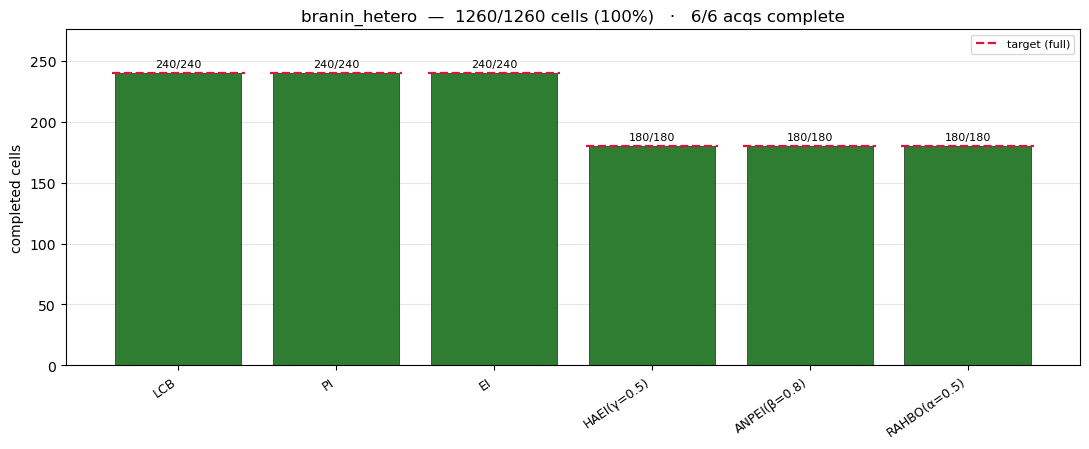

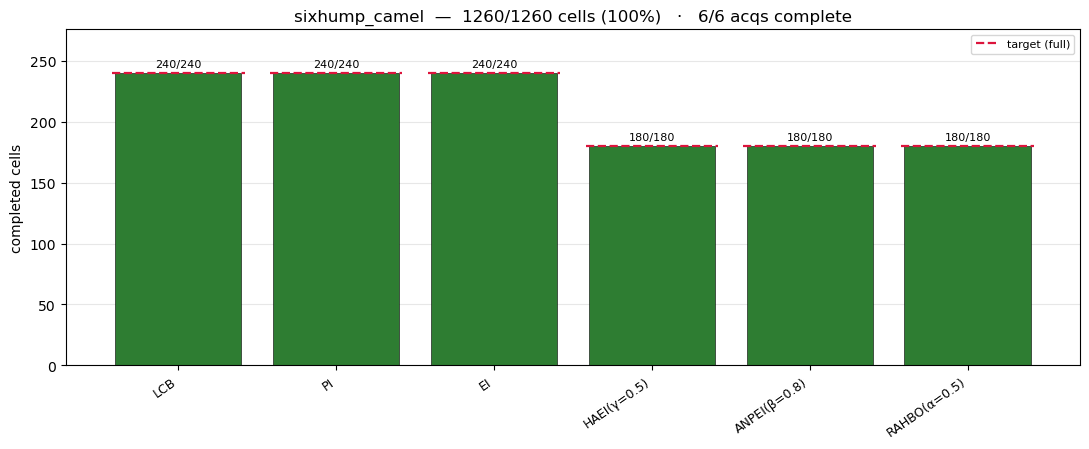

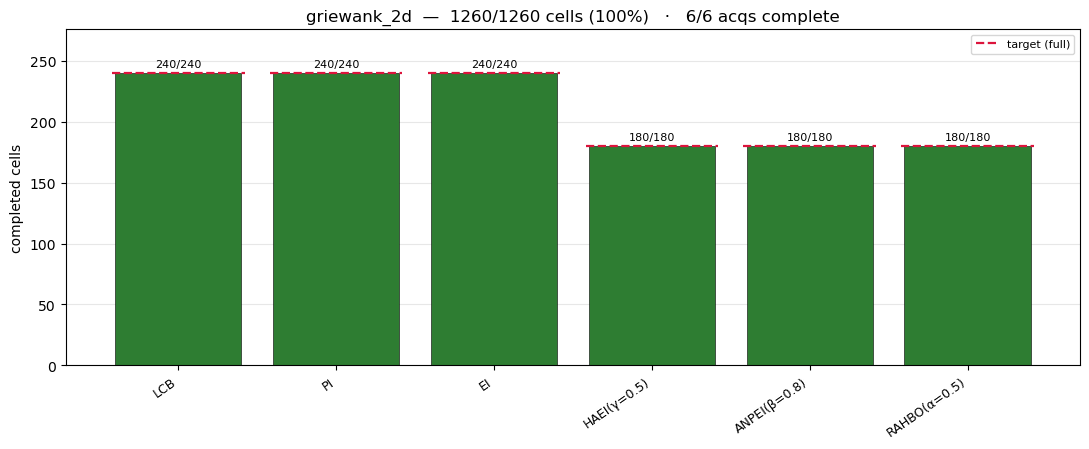

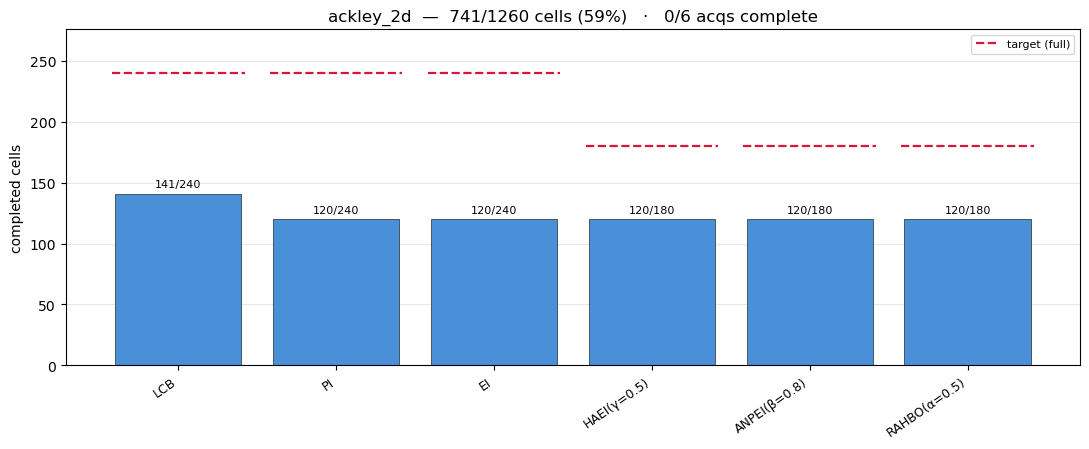

In [3]:
# ---- one progress plot per problem ----
for function in FUNCTIONS:
    labels = [acquisitions.label(a, p) for a, p in CFG]
    counts = np.array([completed(function, a, p) for a, p in CFG])
    tgts   = np.array([target(a) for a, _ in CFG])
    fig, ax = plt.subplots(figsize=(11, 4.6))
    colors = ['#2e7d32' if c >= t else '#4a90d9' for c, t in zip(counts, tgts)]
    bars = ax.bar(range(len(counts)), counts, color=colors, edgecolor='k', lw=0.4, zorder=2)
    for i, t in enumerate(tgts):                       # target line where full completion lives (per acq)
        ax.hlines(t, i - 0.42, i + 0.42, color='crimson', ls='--', lw=1.6, zorder=3,
                  label='target (full)' if i == 0 else None)
    for b, c, t in zip(bars, counts, tgts):
        ax.text(b.get_x() + b.get_width()/2, c + tgts.max()*0.015, f'{int(c)}/{int(t)}',
                ha='center', va='bottom', fontsize=8)
    done, total = int(counts.sum()), int(tgts.sum())
    pct = 100*done/total if total else 0
    ndone = int((counts >= tgts).sum())
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
    ax.set_ylim(0, max(tgts.max(), counts.max(), 1)*1.15); ax.set_ylabel('completed cells')
    ax.set_title(f'{function}  —  {done}/{total} cells ({pct:.0f}%)   ·   {ndone}/{len(CFG)} acqs complete')
    ax.legend(loc='upper right', fontsize=8); ax.grid(axis='y', alpha=0.3)
    fig.tight_layout() 
    plt.show()

In [4]:
# ---- overall roll-up across all problems ----
gd = gt = 0
print(f'{"problem":16s} {"done":>6s} {"total":>6s}  {"%":>4s}')
for function in FUNCTIONS:
    d = sum(completed(function, a, p) for a, p in CFG)
    t = sum(target(a) for a, _ in CFG)
    gd += d; gt += t
    print(f'{function:16s} {d:6d} {t:6d}  {100*d/t if t else 0:4.0f}')
print('-'*38)
print(f'{"OVERALL":16s} {gd:6d} {gt:6d}  {100*gd/gt if gt else 0:4.0f}')

problem            done  total     %
branin_hetero       781   1260    62
sixhump_camel         0   1260     0
griewank_2d           0   1260     0
ackley_2d             0   1260     0
--------------------------------------
OVERALL             781   5040    15
